In [1]:
import torch
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
CUDA_VERSION = torch.__version__.split("+")[-1]
print("torch: ", TORCH_VERSION, "; cuda: ", CUDA_VERSION)

torch:  2.0 ; cuda:  cpu


In [2]:
import os
HOME = os.getcwd()
print(HOME)

c:\Users\stasi\OneDrive\Documents\God_save_the_bugs


## Install YOLOv8

In [3]:
from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.0.112  Python-3.10.9 torch-2.0.1+cpu CPU
Setup complete  (20 CPUs, 15.8 GB RAM, 264.0/930.8 GB disk)


## Install Supervision

In [4]:
#%pip install supervision==0.2.0

from IPython import display
display.clear_output()

import supervision as sv
print("supervision", sv.__version__)

supervision 0.2.0


## Download data

In [6]:
MALL_VIDEO_PATH = "video.mp4"

## Simple YOLOv8 Shopping Mall Example

In [7]:
from ultralytics import YOLO
model_path = os.path.join('.', 'runs', 'detect', 'train', 'weights', 'last.pt')
model = YOLO(model_path)  # load a custom model

**NOTE:** Let's start vanilla YOLOv8 inference pipeline.

In [8]:
import supervision as sv

# extract video frame
generator = sv.get_video_frames_generator(MALL_VIDEO_PATH)
iterator = iter(generator)
frame = next(iterator)

# detect
results = model(frame, imgsz=1280)[0]
detections = sv.Detections.from_yolov8(results)

# annotate
box_annotator = sv.BoxAnnotator(thickness=4, text_thickness=4, text_scale=2)
frame = box_annotator.annotate(scene=frame, detections=detections)

%matplotlib inline
sv.show_frame_in_notebook(frame, (16, 16))


0: 736x1280 (no detections), 157.3ms
Speed: 6.0ms preprocess, 157.3ms inference, 0.0ms postprocess per image at shape (1, 3, 1280, 1280)


: 

: 

**NOTE:** In this demo, our goal is primarily to detect people. Therefore, let's filter out detections related to other classes. By the way, we can also replace our bounding box labels with more human-friendly ones.


0: 736x1280 1 person, 4 bottles, 1 chair, 1 tv, 2 refrigerators, 35.2ms
Speed: 13.2ms pre-process, 35.2ms inference, 2.0ms postprocess per image at shape (1, 3, 1280, 1280)


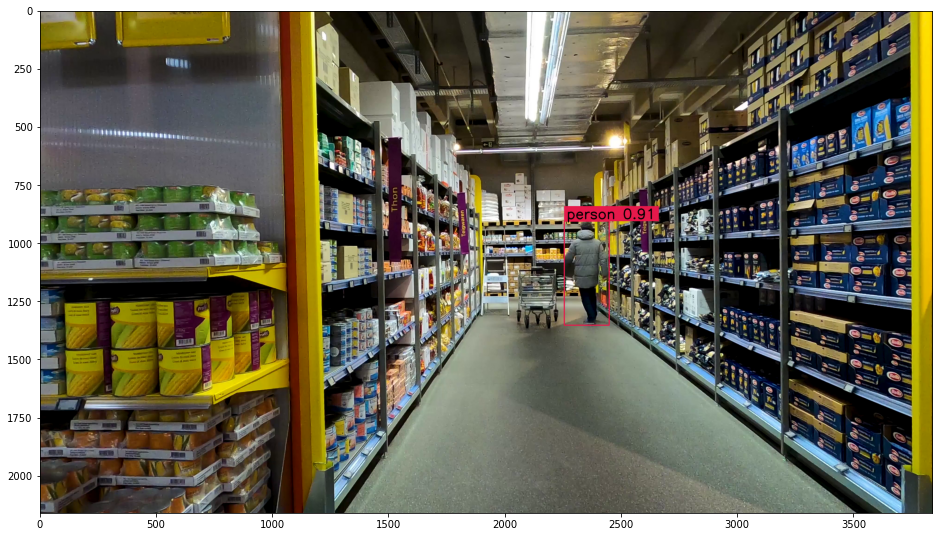

In [ ]:
import supervision as sv

# extract video frame
generator = sv.get_video_frames_generator(MALL_VIDEO_PATH)
iterator = iter(generator)
frame = next(iterator)

# detect
results = model(frame, imgsz=1280)[0]
detections = sv.Detections.from_yolov8(results)
detections = detections[detections.class_id == 0]

# annotate
box_annotator = sv.BoxAnnotator(thickness=4, text_thickness=4, text_scale=2)
labels = [f"{model.names[class_id]} {confidence:0.2f}" for _, confidence, class_id, _ in detections]
frame = box_annotator.annotate(scene=frame, detections=detections, labels=labels)

%matplotlib inline
sv.show_frame_in_notebook(frame, (16, 16))

**NOTE:** Now we can add a polygon zone to the scene and visualize it.

In [ ]:
sv.VideoInfo.from_video_path(MALL_VIDEO_PATH)

VideoInfo(width=3840, height=2160, fps=29, total_frames=1002)


0: 736x1280 1 person, 4 bottles, 1 chair, 1 tv, 2 refrigerators, 44.6ms
Speed: 7.6ms pre-process, 44.6ms inference, 2.1ms postprocess per image at shape (1, 3, 1280, 1280)


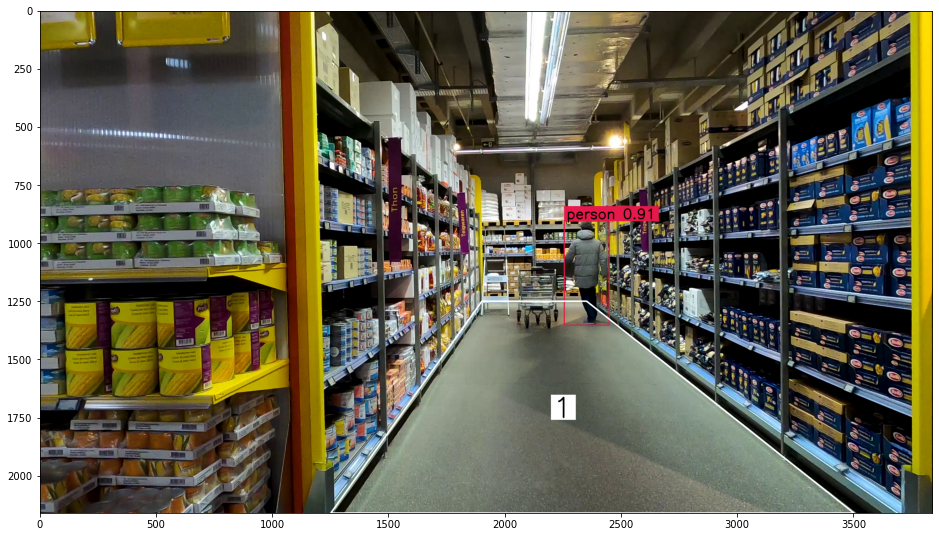

In [ ]:
import numpy as np
import supervision as sv

# initiate polygon zone
polygon = np.array([
    [1900, 1250],
    [2350, 1250],
    [3500, 2160],
    [1250, 2160]
])
video_info = sv.VideoInfo.from_video_path(MALL_VIDEO_PATH)
zone = sv.PolygonZone(polygon=polygon, frame_resolution_wh=video_info.resolution_wh)

# initiate annotators
box_annotator = sv.BoxAnnotator(thickness=4, text_thickness=4, text_scale=2)
zone_annotator = sv.PolygonZoneAnnotator(zone=zone, color=sv.Color.white(), thickness=6, text_thickness=6, text_scale=4)

# extract video frame
generator = sv.get_video_frames_generator(MALL_VIDEO_PATH)
iterator = iter(generator)
frame = next(iterator)

# detect
results = model(frame, imgsz=1280)[0]
detections = sv.Detections.from_yolov8(results)
detections = detections[detections.class_id == 0]
zone.trigger(detections=detections)

# annotate
box_annotator = sv.BoxAnnotator(thickness=4, text_thickness=4, text_scale=2)
labels = [f"{model.names[class_id]} {confidence:0.2f}" for _, confidence, class_id, _ in detections]
frame = box_annotator.annotate(scene=frame, detections=detections, labels=labels)
frame = zone_annotator.annotate(scene=frame)

%matplotlib inline
sv.show_frame_in_notebook(frame, (16, 16))

**NOTE:** Note the number 1 visible in the middle of the zone we painted. Now let's try changing its location and see what happens.


0: 736x1280 1 person, 4 bottles, 1 chair, 1 tv, 2 refrigerators, 35.4ms
Speed: 1.2ms pre-process, 35.4ms inference, 7.4ms postprocess per image at shape (1, 3, 1280, 1280)


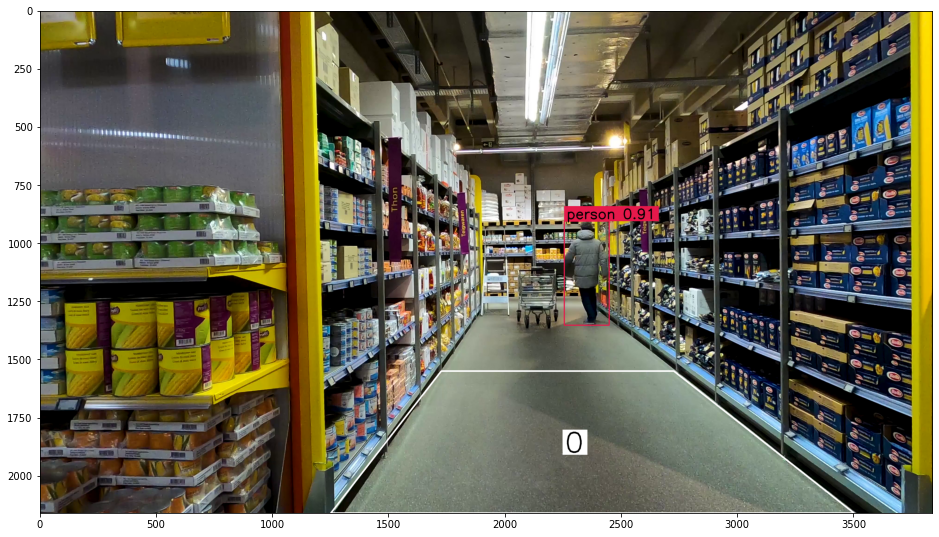

In [ ]:
import numpy as np
import supervision as sv

# initiate polygon zone
polygon = np.array([
    [1725, 1550],
    [2725, 1550],
    [3500, 2160],
    [1250, 2160]
])
video_info = sv.VideoInfo.from_video_path(MALL_VIDEO_PATH)
zone = sv.PolygonZone(polygon=polygon, frame_resolution_wh=video_info.resolution_wh)

# initiate annotators
box_annotator = sv.BoxAnnotator(thickness=4, text_thickness=4, text_scale=2)
zone_annotator = sv.PolygonZoneAnnotator(zone=zone, color=sv.Color.white(), thickness=6, text_thickness=6, text_scale=4)

# extract video frame
generator = sv.get_video_frames_generator(MALL_VIDEO_PATH)
iterator = iter(generator)
frame = next(iterator)

# detect
results = model(frame, imgsz=1280)[0]
detections = sv.Detections.from_yolov8(results)
detections = detections[detections.class_id == 0]
zone.trigger(detections=detections)

# annotate
box_annotator = sv.BoxAnnotator(thickness=4, text_thickness=4, text_scale=2)
labels = [f"{model.names[class_id]} {confidence:0.2f}" for _, confidence, class_id, _ in detections]
frame = box_annotator.annotate(scene=frame, detections=detections, labels=labels)
frame = zone_annotator.annotate(scene=frame)

%matplotlib inline
sv.show_frame_in_notebook(frame, (16, 16))

**NOTE:** Note that now no person is in the zone, and consequently the counter still indicates zero.

Now let's try to process the whole video.

In [ ]:
import numpy as np
import supervision as sv

# initiate polygon zone
polygon = np.array([
    [1725, 1550],
    [2725, 1550],
    [3500, 2160],
    [1250, 2160]
])
video_info = sv.VideoInfo.from_video_path(MALL_VIDEO_PATH)
zone = sv.PolygonZone(polygon=polygon, frame_resolution_wh=video_info.resolution_wh)

# initiate annotators
box_annotator = sv.BoxAnnotator(thickness=4, text_thickness=4, text_scale=2)
zone_annotator = sv.PolygonZoneAnnotator(zone=zone, color=sv.Color.white(), thickness=6, text_thickness=6, text_scale=4)

def process_frame(frame: np.ndarray, _) -> np.ndarray:
    # detect
    results = model(frame, imgsz=1280)[0]
    detections = sv.Detections.from_yolov8(results)
    detections = detections[detections.class_id == 0]
    zone.trigger(detections=detections)

    # annotate
    box_annotator = sv.BoxAnnotator(thickness=4, text_thickness=4, text_scale=2)
    labels = [f"{model.names[class_id]} {confidence:0.2f}" for _, confidence, class_id, _ in detections]
    frame = box_annotator.annotate(scene=frame, detections=detections, labels=labels)
    frame = zone_annotator.annotate(scene=frame)

    return frame

sv.process_video(source_path=MALL_VIDEO_PATH, target_path=f"{HOME}/mall-result.mp4", callback=process_frame)

from IPython import display
display.clear_output()